Randomised Riemannian Hamiltonian Monte Carlo for Bayesian Estimation as a Constrained Distribution Problem

Defined by $g(X,d_{1},d_{2}) = X^{T}X - \mathbb{I}_{p} = 0$, we have $\mathcal{M} := \{(X,d_1 , d_2 ) \in \mathbb{R}^{d \times p}\times \mathbb{R}^{p} \times \mathbb{R}^d \mid g(X) = 0\}$

For $A \in \mathbb{R}^{d \times p}$ with $v_{i} \in \mathbb{R}^{d}$, $i = 1,...,p$ being the column vectors. We define $g_{ij}(A) = v_{i} \cdot v_{j} - \delta_{ij} = 0$


1) Dynamics

In [1]:
import numba
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import time
import random

# Data Extraction

In [2]:
import os
from os import sys

In [3]:
data_matrix = np.zeros((120,2000))


for k in range(1,2001):
    file_location = './cov_shrink_simulations/'
    if k < 10:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_000' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
    
    if 10 <= k < 100:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2              =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_00' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)   
        
    if 100 <= k < 1000:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_0' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    if 1000 <= k:
        #print(k)
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_01_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp1             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_01_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp2             =  np.append(xi_p,xi_m, axis = 0)
        
        file_name         =  'xi_athena_final_shrinkage_lognormal_2zbin_shapenoise_02_02_' + str(k) + '.dat'
        file              =  os.path.join(file_location,file_name)
        dat_file          =  np.genfromtxt(fname=file,  skip_header =1, dtype='unicode', invalid_raise = False)
        xi_p              =  dat_file[:,1]
        xi_m              =  dat_file[:,2]
        xi_p              =  np.reshape(xi_p,(len(xi_p),1))
        xi_m              =  np.reshape(xi_m,(len(xi_m),1))
        temp3             =  np.append(xi_p,xi_m, axis = 0)  
        
    temp12  = np.append(temp1, temp2, axis = 0)
    temp123 = np.append(temp12,temp3, axis = 0)
    #print(np.shape(temp123))
    data_matrix[:,k-1]  = np.reshape(temp123,(len(temp123),))
        


In [4]:
# Astronomical Data
#n = 2000
N = 120

p =  N//6
d =  N
m =  p

In [5]:
n = N*2//3
Data = data_matrix[:N,:2000]

mean = np.mean(Data[:,:n],axis = 1)
var = np.var(Data[:,:n],axis = 1)

    
    
for i in range(2000):
    Data[:,i] -= mean
    Data[:,i] /= np.sqrt(var)


In [6]:
# np.max(Data)

In [7]:
# np.min(Data)

In [8]:
# np.mean(Data,axis = 1)

In [9]:
mean = np.mean(Data[:,:n],axis = 1)

# Data_matrix_2 = np.zeros((N,n))

# for i in range(N):
#     Data_matrix_2[i,:] = Data_matrix_2[i,:] - mean[i]
    
# maximum = np.max(abs(Data_matrix_2))
# print(maximum)

We are sampling from the von Mises-Fisher distribution which has density given by 

$p_{vMF}(X) \propto \exp{(\langle f_{1},x_{1} \rangle + ... + \langle f_{p},x_{p}\rangle)}$

In [10]:

#print(np.mean(abs(np.random.normal(0,1,2000))))

# Preconditioning

[-3.10515502e-16  6.59194921e-17 -4.85722573e-17 -1.04083409e-16
 -1.02348685e-16  7.97972799e-17  3.50414142e-16 -1.73472348e-17
  1.02348685e-16  7.28583860e-17 -5.72458747e-17 -1.21430643e-17
  8.50014503e-17  4.68375339e-17  1.49186219e-16  1.42587832e-16
  2.01661604e-17  5.46437895e-17  6.93889390e-18 -7.39425882e-17
  3.46944695e-17  8.67361738e-18  5.03069808e-17  6.24500451e-17
  1.73472348e-17  1.14491749e-16 -3.46944695e-17  9.71445147e-17
 -5.98479599e-17  1.07986536e-16 -1.97758476e-16 -1.47451495e-16
  1.45716772e-16  2.28983499e-16  4.03323208e-17  4.33680869e-19
 -1.61329283e-16  6.66513286e-17 -1.07552856e-16 -9.83642421e-17
  2.60208521e-17 -1.63064007e-16  5.51642065e-16 -6.86083135e-16
  4.70326902e-16  7.63278329e-17 -3.97251676e-16 -2.32452946e-16
 -1.49619900e-16 -8.50014503e-17  3.71230824e-16 -4.16333634e-17
 -1.04083409e-17  6.59194921e-17 -4.42354486e-17  1.03649728e-16
  3.46944695e-18 -3.81639165e-17 -4.16333634e-17  1.77809156e-17
  6.93889390e-18 -2.77555

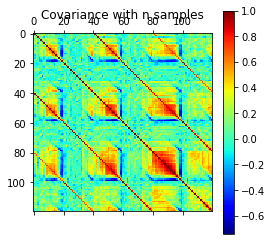

In [11]:
# sample variance
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n
    
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

print(mean2)

plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [12]:
D_2 = np.diag(np.diag(S_small))
Pmat = (S_small - D_2)


EIG = np.linalg.eig(Pmat)
A  = np.zeros((d,p))
for i in range(p):
    A[:,i] = EIG[1][:,i]



D_1 = np.diag(EIG[0][:p])

Approx = np.matmul(A,np.matmul(D_1,np.transpose(A)))
D_2 = np.diag(np.diag(S_small)) - np.diag(np.diag(Approx))
Approx += D_2

# Sampling

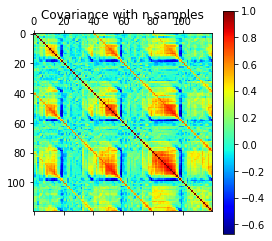

In [13]:
    
plt.matshow(Approx,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [14]:
#p<=d



p =  N//6
d =  N
m =  p


dimension = int(d*p+p+d)
num_of_constraints  = int(p*(p+1)/2)

σ_1 = 2
σ_2 = 2
#Matrix in distribution

@numba.jit(nopython=True)
def vec_to_matrix(q):
    X = np.zeros((d,p))
    for i in range(d):
        for j in range(p):
            X[i,j] = q[j*d+i]
    return X

@numba.jit(nopython=True)
def matrix_to_vec(X):
    #initialising filler array
    x = np.zeros(d*p)
    
    for i in range(d*p):
        i_index = i%d
        j_index =  int((i - i_index)/d)
        x[i] = X[i_index,j_index]
    return x

@numba.jit(nopython=True)
def dot_product(v1,v2):
    dot = 0
    for i in range(len(v1)):
        
        dot += v1[i]*v2[i]
        
    return dot

@numba.jit(nopython=True)
def matmul(matrix1,matrix2):
    a = matrix1.shape[0]
    b = matrix2.shape[1]
    c = matrix2.shape[0]
    rmatrix = np.zeros((a,b))
    for i in range(a):
        for j in range(b):
            for k in range(c):
                rmatrix[i,j] += matrix1[i,k] * matrix2[k,j]
    return rmatrix

@numba.jit(nopython=True)
def matrix_vec_multiplication(A,x):
    v = np.zeros(len(A))
    
    for i in range(len(A)):
        for j in range(len(x)):
                v[i] += A[i][j] * x[j]
    return v


@numba.jit(nopython=True)
def g_ij(q,i,j):
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    if i==j:
        y = np.linalg.norm(X[:,i])**2 - 1
    else:
        y = dot_product(X[:,i],X[:,j])
        
    return y


@numba.jit(nopython=True)
def G(q): #considering i<j.
    
    q_mat = q[:d*p]
    
    X = vec_to_matrix(q_mat)
    
    z = np.zeros((dimension,num_of_constraints))
    
    for i in range(p): #block diagonals
        z[d*i:d*(i+1),int(p*i-0.5*i*(i-1)):int(p*(i+1) - 0.5*i*(i+1))] = X[:,i:]
    
        #vector diagonals
        for j in range(p-i):
            z[(j+i)*d:(j+i+1)*d,int(p*i-0.5*i*(i-1) + j)] += X[:,i]  
    z = z.T #could implement this above
    return z


In [15]:
@numba.jit(nopython=True)
def potential_derv_fast(q):
    #Can check with numerical differentiation.
    
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    
    Σ_inv_T = np.transpose(np.linalg.inv(Σ))

    #Constructing M
    M_kl = 0.5*n*Σ_inv_T 
    
    for k in range(d):
        for l in range(d):
            for r in range(n):
                M_kl[k,l] -= 0.5*dot_product(Data[:,r]-mean,Σ_inv_T[k,:])*dot_product(Σ_inv_T[:,l],Data[:,r]-mean)
    
    #dUdX
    dUdX = np.zeros((d,p))
    
    for i in range(d):
        
        for j in range(p):
            
            for k in range(d):
                
                for l in range(d):
                    
                    if k == i and l == i:
                        
                        dΣ_kl_dX_ij = 2*X[i,j]*d_1[j]
                        
                    elif k == i:
                        
                        dΣ_kl_dX_ij = d_1[j]*X[l,j]
                        
                    elif l == i:
                        
                        dΣ_kl_dX_ij = X[k,j]*d_1[j]
                    
                    else:
                        continue
                    
                    dUdX[i,j] += M_kl[k,l]*dΣ_kl_dX_ij
                    
                
            
    
    #dUd1
    dUd1 = np.zeros(p)
    
    for j in range(p):
    
        for k in range(d):
                
            for l in range(d): 
                    
                dΣ_kl_dD1_jj = X[k,j]*X[l,j]

                dUd1[j] += M_kl[k,l]*dΣ_kl_dD1_jj

        #adding extra term
        dUd1[j] += d_1[j]/(σ_1)**2
    
   
    #dUd2
    dUd2 = np.zeros(d)
    
    for j in range(d):

        dUd2[j] += M_kl[j,j]*1.
        
        #adding extra term
        dUd2[j] += d_2[j]/(σ_2)**2
    
    pot_derv = np.zeros(int(d*p+p+d))
    pot_derv[:d*p] = matrix_to_vec(dUdX)
    pot_derv[d*p:d*p+p] = dUd1
    pot_derv[d*p+p:] = dUd2
    
    return pot_derv

In [16]:
q_initial = list(matrix_to_vec(np.eye(d,p)))
d_1 = abs(np.random.normal(0,σ_1,p))
d_2 = abs(np.random.normal(0,σ_2,d))
q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
x_init = q_initial
#x_init = q_initial
print(x_init)

[1.         0.         0.         ... 3.62320538 1.46395076 0.56300333]


In [17]:
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
potential_derv_fast(q_initial)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  5.790074348449707
time after compiling =  1.5426595211029053


In [18]:
#RATTLE Hamiltonian Flow
@numba.jit(nopython=True)
def RATTLE_with_Potential(x0,v0,t,dt,max_elim_iters):
    n = np.floor(t/dt)
    vn = v0
    qn = x0
    vhalf = v0
    G_q = G(qn)
    
    #Gram Matrix is GG^T
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    
    
    pderv = potential_derv_fast(qn)#potential_derv(qn)
    
    residual_list = np.zeros(num_of_constraints)
    for i in range(int(n)):
        
        
        #solver for Lagrange position multipliers
        Q = qn + vn*dt - 0.5*dt*dt*pderv
        
        #non-linear gaussian elimination
        for k in range(max_elim_iters): #i>j
            for i in range(p):
                for j in range(i,p):
                    g_Q = g_ij(Q,i,j)
                    index = int(i*p - 0.5*i*(i-1) + j-i)
                    
                    residual_list[index] = g_Q
                    if abs(g_Q) < 1e-8:
                        continue
                    G_Q = G(Q)
                    
                    #should be sum of i's and js in indexing below
                    dlambda = g_Q/dot_product(G_Q[index,:],G_q[index,:])
                    Q = Q - G_q[index,:]*dlambda
            #break condition
            if np.all(np.abs(residual_list)<1e-8):
                break

        
        #half step
        vhalf = (Q-qn)/dt
        qn = Q
        
        pderv = potential_derv_fast(qn) #potential_derv(qn)
        G_q = G(qn)
        
        gram = matmul(G_q,G_q.T)
        gram_inv = np.linalg.inv(gram)
        
        #linear solver Lagrange velocity multipliers
        b = matrix_vec_multiplication(G_q,2*vhalf/dt - pderv)
        coeffs_v = matrix_vec_multiplication(gram_inv,b)
        
        #full step
        vn = vhalf - 0.5*dt*pderv - 0.5*dt*matrix_vec_multiplication(G_q.T,coeffs_v)
       
    return qn,vn

# Checks

In [19]:
X = np.array([[1,2,3], [4,5,6],[7,8,9]])
#print(X[:,1:])
#g_ij checked
#G checked for what I want.
#print(X.T,X)
M = np.eye(d, p)
M = matrix_to_vec(M)
gram = matmul(G(M),G(M).T)
"G matrix should be #constraints by dimension 0.5*p*(p+1) by p*d" 
#6 by 9
print(gram)
M = np.eye(d, p)


[[4. 0. 0. ... 0. 0. 0.]
 [0. 2. 0. ... 0. 0. 0.]
 [0. 0. 2. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 4. 0. 0.]
 [0. 0. 0. ... 0. 2. 0.]
 [0. 0. 0. ... 0. 0. 4.]]


2) Event Time Sampling


In [20]:
#Sampling Event Times
@numba.jit(nopython=True)
def time_exp(lam):
    t = np.random.exponential(lam)
    return t

3) Gaussian Sampling on Tangent Space

In [21]:
@numba.jit(nopython=True)
def tangent_space_gaussian(q):
    
    
    v = np.random.normal(0.,1.0,dimension).T
    
    
    G_q = G(q)
    
    
    gram = matmul(G_q,G_q.T)
    gram_inv = np.linalg.inv(gram)
    
    proj_matrix = np.eye(dimension) - matmul(G_q.T,matmul(gram_inv,G_q))
    
    #sample 3d gaussian and then project onto tangent space.
    v = matrix_vec_multiplication(proj_matrix,v)
    
    return v

#check
Z = tangent_space_gaussian(x_init)
T_X = vec_to_matrix(Z[:d*p])  
X = vec_to_matrix(x_init[:d*p])
print('constraint check =',matmul(T_X.T,X) + matmul(X.T,T_X))
print('Should be Gaussian no constraints =',Z[d*p:])

constraint check = [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [22]:
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time before compiling = ',t2-t1)
t1 = time.time()
RATTLE_with_Potential(q_initial,Z,0.01,0.001,50)
t2 = time.time()
print('time after compiling = ',t2-t1)

time before compiling =  28.63986349105835
time after compiling =  22.965543508529663


In [23]:
@numba.jit(nopython=True)
def U(q):
    
    X = vec_to_matrix(q[:d*p])
    
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    Σ_inv = np.linalg.inv(Σ)
    
    #likelihood
    pot = 0.5*n*np.log(np.linalg.det(Σ)) + 0.5*n*p*np.log((2*np.pi))
    for i in range(n):
        Bx = matrix_vec_multiplication(Σ_inv,Data[:,i]-mean)
        pot += 0.5*dot_product(Data[:,i]-mean,Bx)
        
    #prior
    #don't need uniform prior because it's constant
    pot += 0.5*np.log(2*np.pi*(σ_1)**2)
    pot += 0.5*dot_product(d_1,d_1)/(σ_1)**2
    
    pot += 0.5*np.log(2*np.pi*(σ_2)**2)
    pot += 0.5*dot_product(d_2,d_2)/(σ_2)**2
    
    return pot


# @numba.jit(nopython=True)
# def f(q):
    
#     z = U(q)
    
#     return z

@numba.jit(nopython=True)
def hamiltonian(x,v):
    return U(x) + 0.5*dot_product(v,v)

In [24]:
def Potential_approx_deriv(q,ϵ):
    δV = np.zeros(len(q))
    for i in range(len(q)):
        h = np.zeros(len(q))
        h[i] = ϵ
        δV[i] = (U(q+h)-U(q-h))/(2*ϵ)
    return δV

In [25]:
@numba.jit(nopython=True)
def f(q):
    X = vec_to_matrix(q[:d*p])
    d_1 = q[d*p:d*p+p]
    d_2 = q[d*p+p:]
    
    D_1 = np.diag(d_1)
    D_2 = np.diag(d_2)
    
    Σ = matmul(matmul(X,D_1),np.transpose(X)) + D_2
    return Σ

In [26]:
#Testing 
q_initial = list(matrix_to_vec(A))

d_1 = np.diag(D_1) #abs(np.random.normal(0,σ_1,p))
d_2 = np.diag(D_2) #abs(np.random.normal(0,σ_2,d))

q_initial += list(d_1)
q_initial += list(d_2)
q_initial = np.array(q_initial)
x_init = q_initial
#x_init = [0.00328776223101419, 0.05372878100469903, -0.04268237792516536, -0.04314239783106904, -0.06041094493793081, -0.1301218947578807, -0.1434253501974252, -0.07630730054781885, -0.16224162960037067, -0.12300500960876336, -0.12878687285931537, -0.21121994856287563, -0.13086721476621116, -0.1958365597527654, -0.18809239112321705, -0.19303911258773074, 0.032701867025276665, -0.04060755973385071, 0.158731005755935, 0.1051418005753199, -0.02611646214737455, 0.004302894946752569, 0.02984092481858578, -0.0434973983442941, 0.02180307447294531, 0.008064933849501372, -0.012607783970091177, 0.016746505511265383, -0.07382484456973121, 0.019913130008820452, 0.05008344984909636, -0.07069616017679099, -0.058839757342624165, -0.0588232829517067, -0.03916116242716925, -0.014491408030935831, 0.02913585304831869, -0.1372929149350587, -0.18803435860700105, -0.1442881528919413, 0.023021820746117357, -0.010289421069325483, -0.13659717808838345, -0.11862343209956366, -0.12343454911693065, -0.18607087952060802, -0.19643357876579498, -0.13832604329690099, -0.17545549316196715, -0.21305380961920323, -0.18865705735677904, -0.24860376811329055, -0.19972185312777566, -0.21183650490985245, -0.19471855249551867, -0.18780851081660405, 0.020566156520253013, 0.029542879331366758, 0.22322400683511162, 0.22528641444151448, -0.017400330649180763, 0.16574564234372194, 0.1078396224506267, 0.045250714944790466, 0.15125420908812282, 0.04128679823209209, 0.10087756748026733, 0.17210130798120452, -0.014559918277016288, -0.1391009712462882, 0.2039928442954615, 0.14943515045087208, -0.0112690350595983, -0.05747469993651938, -0.0184203851604838, -0.17298116630867413, -0.1820381647253794, -0.21106586663887153, 0.18254769696879827, 0.041428385611212995, -0.030723285021681944, -0.004724976558287926, 0.14981191886841538, -0.00855854296220875, 0.2863832253078038, -0.03476461653890725, -0.038751311000218, 0.0697494178638382, 0.014987269775152244, -0.016978888346949706, 0.06776355539084677, 0.031850655449418085, -0.06335383897134426, -0.001464690454570273, 0.028141928170278212, 0.21723034437798786, 0.23331723811674573, 0.17797756576365656, 0.08898197261748615, -0.011733280072994835, -0.04446514626970345, 0.18350052363200037, 0.12726798069394887, 0.05005085665249099, 0.13768708898730117, 0.07715760884072892, 0.10860467816656418, 0.20714960039234145, 0.053022428639877765, -0.09077938104767673, 0.16701853549822082, 0.12935819546471364, -0.08762130004320749, -0.09231080285656282, -0.1382764114865466, -0.21197361364546602, -0.20968332751429017, -0.15063224292786992, 0.1630169064456227, 0.1890914502855335, 0.14984370815444006, -0.0675578019892524, -0.15612656935434338, -0.0035731495782797052, -0.11900569726633127, 0.06010082658709802, 0.23686125312089987, -0.04110573186035009, 0.07420462846028293, 0.2939866570975338, 0.2218499165577216, 0.11906663763422698, 0.08803775554433382, -0.18773129755675802, -0.08279303840443028, 0.06698873574960915, 0.10066767813906961, -0.012767978012046828, 0.14934933607152465, 0.10758141229590953, 0.166258443137082, 0.02310278490679644, -0.028258836711206606, -0.23395811519686452, -0.20947406841579272, 0.14862016846113482, 0.030066414681878196, 0.20176989328840766, 0.03138191042641897, 0.09533414091711533, -0.1099883911037241, -0.07717708101649214, 0.07856974944558733, 0.1797349886845669, -0.027304567807673562, 0.09812902246743313, -0.2122160002053675, 0.10532240608443245, 0.1858118499275981, -0.10278337925882364, 0.12820093582933842, -0.10382668203951698, -0.1164391483748483, -0.09062669212336973, 0.13216045962421608, 0.01953071949025919, 0.05727461803354308, -0.16417944152522082, -0.028435808741332218, -0.011192144460928326, 0.07210185027897124, 0.019911867271366155, -0.055640266861875044, -0.1552187862091643, -0.0516376855900023, 0.026414502949246146, 0.03544663666815998, -0.2339595875953328, 0.029355114584523796, 0.24225554214848605, 0.010144819934901449, -0.10641375195681826, 0.09805421402024665, 0.10862813236235384, -0.025074426812494516, -0.018276337222229717, 0.1933000909827392, 0.16279871668610157, 0.16521564297713148, 0.057316041839188626, -0.195067439479207, -0.28689133234696823, -0.27362424493790255, -0.17423008267748633, -0.08161425177243473, 0.024193359881344995, -0.24926803377282994, 0.01995227830530415, 0.002002288073932708, 0.11917728726902904, 0.08491009586021149, 0.005761006190401543, -0.23945753509700846, 0.01668598104178209, 0.08028521799192671, 0.01532254624915075, 0.21334093239644475, -0.0006708813615391184, -0.04885550749999052, 0.004803894591076945, 0.05370636676742406, 0.2076635838344708, -0.03173184949294312, -0.0355753711020884, 0.10617741388864944, 0.01627293938681175, -0.16324736737646262, 0.0952326847702214, -0.10503417314998212, -0.18766818507428387, 0.012387116238807516, -0.08487677115751115, 0.07935414839348101, 0.09203006048542114, 0.05476163548679255, 0.03271991306859244, 0.22846022803078198, 0.19055238715341183, 0.14640046428773013, 0.11696758094081736, -0.1090593434486632, -0.12860435631741465, -0.16166483491354114, -0.10059702086300999, 0.058769253194356844, 0.1480401159756985, -0.12986793994705595, 0.09383339883774214, -0.14752618643808205, 0.11668112210217192, 0.08969329714004474, -0.061161920434924036, -0.03192750557855484, 0.3311109437686544, -0.011030794390687437, -0.016687904904708045, -0.23296830699643917, 0.03930753369455724, -0.016977449571123873, -0.015159010398648871, 0.09458874236676758, 0.06027673408850473, -0.05241220175979473, -0.3943852942822559, 0.00935732297996928, 0.03580657881511945, -0.003955642200131934, 0.08264269185242881, -2.5555895865974186e-05, -0.03332631935076859, -0.06989724408303782, -0.12157221929709532, -0.01373692614948574, -0.0018093205802988707, 0.038787096348082147, 0.32389987209733806, -0.1136943836814921, 0.00601304097986944, -0.03563817353919896, 0.15281966927348753, 0.13866819460166552, -0.06919535819818395, 0.0794183540132008, -0.1363257001327357, 0.025128923059235777, -0.0020687842090890067, 0.14356680527509746, 0.01377567864338642, 0.035736294130753736, -0.14202416396542666, 0.016416294340183765, -0.10750821069854337, -0.07258882792268498, 0.33511808207821664, -0.15299668440006117, -0.0720150744461515, -0.21578637958365718, -0.005398008896985806, 0.11837858616216296, 0.17186803935767242, 0.12785871101020652, 0.178206482033825, 0.07574469565536088, -0.21194389968144844, 0.07776903337120626, 0.0007728638683995893, -0.03276027420114019, 0.0021403605313742987, -0.013499115680503705, -0.17540074734168182, -0.2033077296407506, 0.018681534528647768, 0.035259851564365806, 0.23373864118649182, -0.08838973084936237, -0.02254761872241459, 0.24629169708016269, -0.09099723388092412, -0.0448358225422494, -0.07255502695052285, 0.15041720419583432, 0.04344195299193531, -0.05369065994696919, 0.05993681078115966, -0.15644415279204124, 0.11475379342519092, 0.3079342532835731, -0.029542039408137582, 0.10457326478798389, -0.07004562406872884, -0.002319271433161928, 0.03091052730882517, -0.04505302041067614, -0.013182507065307261, 0.04379600809804889, 0.2335722641257167, -0.07436805641359953, -0.037130976767279444, 0.027346925155069427, -0.02493437259083703, -0.13279904373004653, 0.19998314520590885, 0.2596853791095976, 0.1350714922495034, 0.08677959066947408, -0.11385786734464466, 0.07653457576461434, -0.14293640469147206, -0.19867882472757842, 0.15087913803852462, -0.16636020156222728, 0.0405425963368075, 0.19870800506670816, 0.2513251981059561, -0.05900141601142073, 0.1173569429551824, 0.22008983058263398, -0.03756288150580971, -0.0755942635836651, -0.10574741681066369, 0.0030498968595357137, -0.09073554004242228, -0.12999918741012445, -0.08785583307844126, -0.16170769519271994, 0.032780397523527904, 0.13595521641068437, 0.10921741724499714, 0.0917578355331389, -0.05100346750570352, 0.19500341372227065, 0.4548692243830909, -0.08503313873190377, -0.013102471658350922, 0.16754846071463486, -0.1482727811972755, 0.12349494506793714, 0.050240367073467816, -0.05328238034944332, -0.06163148968938641, -0.05919668077490248, -0.12122095785929818, 0.01680946517323606, -0.015294930777687406, 0.08114193332908717, 0.005101818103848899, 0.0662370340946996, 0.08409388985013445, 0.04008685254871183, -0.05402974395032732, 0.0381044453387922, -0.020897040606621915, -0.05528539793608308, 0.07666297145014704, -0.08636566340827873, 0.1911771885461856, -0.058607063054896644, 0.10281817086873328, -0.028468886276289625, 0.04053274713847756, 0.01696559016006118, -0.059741504142679584, 0.0708830092528869, 0.04155815000440045, -0.03832763089931173, 0.026915275607716966, -0.10287227549622809, -0.0047484795380106, -0.010256972562439171, -0.0919056987788333, 0.3775213612739799, 0.49055081756931285, -0.09550582379984568, 0.05421208858808096, 0.047915533029938125, -0.13815402818017003, 0.1510113616487324, 0.11306489806327555, 0.016174508754604685, -0.02981847684461842, 0.0008897472791053803, -0.02917976745111822, 0.0041909641924870325, 0.045690766308936696, 0.08990933075469126, 0.10221957906316481, 0.11197039413600682, 0.1278595602825794, 0.07098676602279037, -0.14098773688976052, -0.03170279132926467, 0.10474436943827053, -0.07372395982616371, 0.08574812365745273, -0.03401439671108848, 0.06665500132655867, -0.2017072725044343, 0.3512053437537226, 0.1584615082184999, 0.11757898464506099, 0.20828524235502469, -0.07418816736728098, -0.02783447103741664, 0.10941529211774974, 0.003840109463652209, 0.009516547027067102, 0.07403045222066405, -0.04715046263877687, -0.2077389937482313, 0.06269826591543072, -0.022692515096270748, -0.0025096358397839217, -0.013159847911694724, -0.14753699377123777, -0.0459874994840735, 0.10711556535025323, -0.2974694938435771, -0.2982455783722961, -0.12313701964112798, -0.07143956323883546, -0.0020766613774657536, 0.01788854646930309, -0.05724164886829789, -0.06073501120993281, 0.07019299804399368, -0.06237954316188378, -0.1418418420029502, 0.09758021592816185, 0.05004816856089296, 0.1155647106754516, -0.07454122902752967, 0.1145280789627215, -0.1275474461511646, 0.06711856930574794, 0.15507111614853356, 0.05821317238674422, -0.2524806499233976, 0.1857520886876065, -0.11614312049617175, -0.16155662247889008, -0.015558943463260725, -0.20012301247739628, -0.2289717403113757, 0.02051095188056895, -0.02784931596955848, 0.1633473992416327, 0.0011489600211546031, -0.08072186725617161, -0.11090393515133107, 0.10315001000926612, 0.009196513905658784, -0.09353465574731105, -0.08810055471795188, -0.30967885559886155, -0.0008962043989569908, 0.04304472956127337, -0.1403201796299825, 0.27875744412918496, -0.06302354474008015, 0.14333125522364876, 0.05820286613710122, 0.06922886230758461, -0.09186745559629196, 0.006885293503420944, -0.04190660697103727, 0.05349415034011047, 0.22230760819484524, 0.1893386424933598, 0.2345366659301284, -0.12384457176264896, -0.00042279626473461067, 0.0771165273024552, 0.052925650143498246, 0.16064319717139025, -0.048031988325397505, 0.02394917105998743, 0.08680728834459815, -0.09990648480097367, 0.025724168893480004, 0.24627794290406416, -0.05447116419427434, -0.1089093817479494, -0.006772371187678944, 0.08022032022780573, 0.021255382053551507, 0.17173382519788735, 0.05074285990348231, 0.11365380917182283, -0.19846301566448785, -0.06335096499853572, -0.1304160258425687, -0.03635946551112723, 0.04000957091515729, -0.22551129998368694, -0.06181776981684555, 0.09191138065975644, -0.029534697888979975, 0.32514489925428197, 0.1512121456714007, 0.13721358251119645, 0.06493884376357256, 0.02479662447887829, -0.08373115448153393, -0.11241458276895908, -0.06456306966528835, 0.08460697292177723, 0.16787098518373844, 0.1937012408832492, 0.16016668027831238, -0.04387985913068447, -0.11528576721057107, -0.06522064459269347, -0.11886136560144456, -0.22137880247716585, 0.0758148181097334, 0.1007741392308622, -0.029737944860370666, -0.09920461091000903, 0.035881459174482266, -0.10130664668144891, 0.2729402335011678, -0.36697693897520617, -0.13804684123755523, -0.10380966040836064, 0.04869356530615378, -0.0673386267820482, -0.02243079642478676, -0.11796330155608346, 0.12178999325351403, -0.07954860426810659, -0.21549465427350406, -0.10954397612490269, -0.2598261688937413, -0.06034967681151328, 0.06644459101653948, 0.038840208782265816, -0.08771431622387439, 0.12892048272238474, -0.02014669916258736, 0.023862754313270604, 0.15097232730242346, 0.12937567951528042, -0.1290219126739717, 0.19111586863953114, 0.17835386471553005, -0.09667832162441578, 0.05258548570842109, 0.11688540511278453, 0.07777823992502832, 0.11365709398839052, -0.00490532883438534, 0.007793897636822071, 0.029425664488474043, -0.1617670971836447, -0.11707650762334368, -0.06348691317094142, 0.042211252656949395, -0.04610225350296374, -0.05825162318907256, 0.0445417606975536, 0.2950020665220228, -0.17451759278411774, 0.13147988657138485, 0.01686466943795868, 0.07869389463356244, 0.011762506791152205, 0.18675453003852913, -0.13928564603541135, -0.05909895344186102, -0.1276672469026351, 9.231515038191901, 3.768722521688607, 1.4467064780685908, 2.6391930373316566, 1.6731395997953904, 2.1192721843120066, 2.0015177866660605, 1.1300003654113202, 2.080568166469848, 1.1672003691565243, 0.4024555044675866, 0.042987931445844424, 0.767693924395072, 0.05046871895373787, 0.8370776283128218, 1.0827319412279202, 0.012474274822817074, 0.022629886830853436, 0.5113451364434098, 0.32992896667520605, 0.025145355694535125, 0.009401778367403328, 0.6286043005039399, 0.07836746062814956, 0.2855022373966502, 0.4015720089621355, 0.1771371271390078, 0.5716169801613619, 0.3820761389625656, 0.7422587891814536, 0.555650302263661, 0.5506858852831619, 0.7209673265274748, 1.0717596761648338, 0.6625678833870368, 1.4709136253127377, 0.6473540820737415, 1.094146261776381, 0.6547639271909828, 0.7157070757028957, 0.7730143190151237, 0.8596732122940582, 0.9523506154383595, 0.6861633162792448, 0.9216661863300267, 0.5486375185776781, 0.5996473001114555, 1.1960618271768921, 0.6690490734759815, 0.4260388898003282, 0.5518853166534646, 0.013028039933404682, 0.6296548610533839, 0.005105987086074142, 0.9918355968349206, 0.8584151300972234, 0.002350403004532306, 0.0030736183750301694, 0.36907627523044895, 0.6120578593080847, 0.0074196103696586545, 0.004737021970060441, 0.404666995427007, 0.04274227656443766, 0.16930211752166316, 0.3323631323551648, 0.29864152682208334, 0.6561401996532698, 0.37066721661307866, 0.42844180000296356]

x_init = np.array(x_init)

772.4750807502107


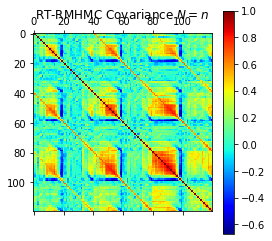

In [27]:
print(U(x_init))
plt.matshow(f(x_init),cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N=n$')
plt.show()
#4 before

In [28]:
print(U(x_init))
t1 = time.time()
p1 = potential_derv_fast(x_init)
t2 = time.time()
p2 = Potential_approx_deriv(x_init,0.000000001)
t3 = time.time()
print('sup|grad_exact - grad_num| =',max(p2-p1))
print('Exact time = ',t2-t1)
print('Numerical time = ',t3-t2)

772.4750807502107
sup|grad_exact - grad_num| = 0.0029167465498218803
Exact time =  1.5685510635375977
Numerical time =  42.111976861953735


4) Simulation

In [29]:
#Initialise
T = 0.01
num_of_events = 3
dt = 0.001

In [30]:
@numba.jit(nopython=True)
def RRHMC(num_of_events,dt_max,T,x_init):
    
    #Exponential Expected Value
    rate = T
    x = x_init
    
    position_list = [x_init]
    v = tangent_space_gaussian(x)
    
    accept = 0.
    gradient_evaluations = 0
    
    for i in range(num_of_events):
        
        t = time_exp(rate)
        L = np.ceil(t/dt_max)
        
        dt = t/L
        
        h = hamiltonian(x,v)
    
        xnew,vnew = RATTLE_with_Potential(x,v,t,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #adding in rejection for non-positive diagonal matrices.
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
            

        
        position_list.append(x)
        
        v = tangent_space_gaussian(x)
        if i%10==0:
            print(i)
        
        
    return position_list

In [31]:
@numba.jit(nopython=True)
def RHMC(num_of_events,dt,T,x_init):
    
#     x = list(matrix_to_vec(np.eye(d,p)))
#     x += list(np.ones(d + p))
    x = x_init
    #initialisation of x on V_{d,p} \times \mathbb{R}^p 
    #                        \times \mathbb{R}^d
    v = tangent_space_gaussian(x)
    
    position_list = [x]
    
    
    for i in range(num_of_events):
        
        h = hamiltonian(x,v)
        
        xnew,vnew = RATTLE_with_Potential(x,v,T,dt,1000)
        
        h_new = hamiltonian(xnew,vnew)
        
        #metropolis hasting step
        #with reject with positivity constraint
        d_1 = xnew[d*p:d*p+p]
        d_2 = xnew[d*p+p:]
        
        
        u = np.random.rand()
        if u <= np.exp(-h_new+h) and min(d_1)>0 and min(d_2)>0:
            x = xnew
        
        position_list.append(x)
        v = tangent_space_gaussian(x)  
        if i%10==0:
            print(i)
            
    return position_list

In [32]:
t = time.time()
position = RRHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('RT time =',elapsed)
t = time.time()
position = RHMC(num_of_events,dt,T,x_init)
elapsed = time.time() - t
print('DT time =',elapsed)

0
RT time = 87.72770190238953
0
DT time = 83.03368473052979


# Check

In [33]:
#Initialise
#T = 0.1
num_of_events = 10000
dt = 0.001
N = 10
T = N*dt
#ensure positivity
#log normal prior

In [34]:
position = RRHMC(num_of_events,dt,T,x_init)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630


LinAlgError: Array must not contain infs or NaNs.

In [ ]:
first_entry_list = []
first = 0
burn = 10000
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    first += U(position[i+burn])
    first_entry_list.append(first/(i+1))

In [ ]:
plt.plot(first_entry_list)
plt.title('U')
plt.xlabel('number of samples')

In [ ]:
#trace plots

In [ ]:
last_entry_list = []
last = 0
burn = 10000
for i in range(len(position)-burn):
    mat = f(position[i+burn])
    
    last += mat[0,-1]
    last_entry_list.append(last/(i+1))

In [ ]:
plt.plot(last_entry_list)
plt.title('Trace')
plt.xlabel('number of samples')

In [ ]:
burn = 10000
Σ_ave = np.zeros((d,d))
for i in range(num_of_events-burn):
    Σ_ave += f(position[i+burn])/(num_of_events-burn)
    #print(len(position[i+burn]))

In [ ]:
S = Σ_ave
print(S)

In [ ]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('RT-RMHMC Covariance $N = 25$')
plt.show()
#4 before
#plot increase in maximum element

In [ ]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

In [ ]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
S_inv = np.linalg.inv(S)

In [ ]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

In [ ]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# True Covariance Matrix

In [ ]:
mean1 = np.zeros(d)
for i in range(2000):
    mean1 += Data[:,i]/2000

In [ ]:
S = np.zeros((d,d))
for i in range(2000):
    x = Data[:,i] - mean1
    S += np.outer(x,x)/2000

In [ ]:
print(S[-1,-1])
print(S[0,0])

In [ ]:
plt.matshow(S,cmap='jet')
plt.colorbar()
plt.title('Covariance with 2000 samples')
plt.show()

In [ ]:
log_S = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S[i,j] = np.log(abs(S[i,j]))

In [ ]:
plt.matshow(log_S,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
S_inv = np.linalg.inv(S)

In [ ]:
plt.matshow(S_inv,cmap='jet')
plt.colorbar()
plt.show()

In [ ]:
log_S_inv = np.zeros((d,d))
for i in range(d):
    for j in range(d):
        log_S_inv[i,j] = np.log(abs(S_inv[i,j]))

In [ ]:
plt.matshow(log_S_inv,cmap='jet')
plt.colorbar()
plt.show()

# Using n points

In [ ]:
mean2 = np.zeros(d)
for i in range(n):
    mean2 += Data[:,i]/n

In [ ]:
S_small = np.zeros((d,d))
for i in range(n):
    x = Data[:,i] - mean2
    S_small += np.outer(x,x)/n

In [ ]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
#print(list(np.diag(S)))

In [ ]:
#print(list(position[-1][:d*p]))

In [ ]:
#print(list(position[-1]))

In [ ]:
#np.trace(S)

In [ ]:
#print(list(position[-1]))

In [ ]:
S_True = S#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
Σ_est = Σ_ave#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
small_S = S_small#*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
np.linalg.norm(S_True - Σ_est,'fro')/np.linalg.norm(S_True)

In [ ]:
np.linalg.norm(S_True - small_S,'fro')/np.linalg.norm(S_True)

In [ ]:
plt.matshow(S_small,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
True_S = S_True*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
Σ_est = Σ_ave*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
small_S = S_small*np.outer(np.sqrt(var),np.sqrt(var))

In [ ]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

In [ ]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

In [ ]:
plt.matshow(Σ_est,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(small_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(True_S,cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
np.linalg.norm(True_S - Σ_est,'fro')/np.linalg.norm(True_S)

In [ ]:
np.linalg.norm(True_S - small_S,'fro')/np.linalg.norm(True_S)

In [ ]:
# plt.matshow(True_S-Σ_est,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

In [ ]:
# plt.matshow(True_S-small_S,cmap='jet')
# plt.colorbar()
# plt.title('Covariance with n samples')
# plt.show()

In [ ]:
plt.matshow(np.log(abs(np.linalg.inv(True_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(np.log(abs(np.linalg.inv(Σ_est))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()

In [ ]:
plt.matshow(np.log(abs(np.linalg.inv(small_S))),cmap='jet')
plt.colorbar()
plt.title('Covariance with n samples')
plt.show()